# Workbook 36 — heterogeneous core compression and central-trigger timing

The pressure-chamber model supplies one outer-boundary radius and therefore one average compression. This workbook introduces the minimum heterogeneity needed to discuss a central DT trigger: tagged Lagrangian fuel zones receive the surface compression waveform only after a finite inward communication delay, then converge at the common stagnation time.

The output is a time profile for local density compression at the outer fuel, mid-radius fuel, and center. It is a kinematic timing model—not radiation hydrodynamics—and does not calculate shock entropy, instability, or mix.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from cno_sweep.heterogeneous_compression import (
    central_trigger_snapshot,
    compression_crossing_time_s,
    converging_kinematic_profile,
)
from cno_sweep.ignition_timing import screen_central_dt_hotspot
from cno_sweep.layered_driver import evolve_layered_pressure_pulse
from cno_sweep.n15_pusher import additive_volume_density


## Fixed mechanical trajectory

The reference is a 100-m-radius Constantine fuel sphere surrounded by the current one-N15-per-core-unit Trajan driver and 4:1 lead-tamper mass ratio. This is the existing optimistic cold mechanical trajectory, rescaled—not a new fusion optimization.

In [2]:
R0_m = 100.0
carbon_density_kg_m3 = 2267.0
helium_density_kg_m3 = 125.0
core_density_kg_m3 = 17.0 / (13.0 / carbon_density_kg_m3 + 4.0 / helium_density_kg_m3)
implosion = evolve_layered_pressure_pulse(
    event_id='constantine-100m-kinematic-timing',
    initial_core_radius_m=R0_m,
    initial_core_density_kg_m3=core_density_kg_m3,
    initial_abundances={'c13': 1.0, 'he4': 1.0},
    driver_n15_loaded_per_core_unit=1.0,
    driver_proton_ratio=4.0,
    n15_burn_fraction=1.0,
    dt_pairs_loaded_per_core_unit=0.0,
    dt_burn_fraction=0.0,
    dt_neutron_deposition_fraction=0.0,
    driver_density_kg_m3=additive_volume_density(4.0),
    tamper_to_driver_mass_ratio=4.0,
    tamper_density_kg_m3=11340.0,
    burn_duration_over_characteristic_time=0.1,
)
minimum_communication_speed = R0_m / implosion.peak_time_s
pd.DataFrame([
    {'quantity': 'initial core radius', 'value': R0_m, 'units': 'm'},
    {'quantity': 'stagnation time', 'value': implosion.peak_time_s * 1e6, 'units': 'us'},
    {'quantity': 'surface-average peak compression', 'value': implosion.peak_compression_ratio, 'units': 'ratio'},
    {'quantity': 'peak compressed radius', 'value': implosion.peak_core_radius_m, 'units': 'm'},
    {'quantity': 'minimum center-reaching communication speed', 'value': minimum_communication_speed / 1e6, 'units': 'Mm/s'},
]).set_index('quantity')

,value,units
quantity,,
initial core radius,1.000000e+02,m
stagnation time,4.429568e+01,us
surface-average peak compression,2.911136e+06,ratio
peak compressed radius,7.003458e-01,m
minimum center-reaching communication speed,2.257556e+00,Mm/s


## Kinematic convergence rule

For initial radius coordinate $x=r_0/R_0$, compression information first arrives at

$$t_a(x)=\frac{(1-x)R_0}{u_c}. $$

After arrival, that zone follows the same normalized log-compression waveform as the outer boundary, compressed into the time remaining before common stagnation. Thus the outer zone starts first; the central zone remains cold longest and then compresses fastest. This is the intended multiple-shock/convergent timing limit. It is prescribed kinematics and cannot determine whether the required shock strengths are stable or attainable.

In [3]:
profiles = {}
for speed_multiple in (1.25, 2.0, 4.0):
    profiles[speed_multiple] = converging_kinematic_profile(
        trace=implosion.trace,
        initial_radius_m=R0_m,
        initial_density_kg_m3=core_density_kg_m3,
        communication_speed_m_s=speed_multiple * minimum_communication_speed,
    )
arrival_rows = []
for speed_multiple, profile in profiles.items():
    for coordinate, arrival in zip(profile.mass_coordinate_fraction, profile.arrival_time_s):
        arrival_rows.append({
            'communication speed/minimum': speed_multiple,
            'initial radius coordinate x': coordinate,
            'compression-arrival time (us)': arrival * 1e6,
            'fraction of stagnation time': arrival / profile.peak_time_s,
        })
pd.DataFrame(arrival_rows).set_index([
    'communication speed/minimum', 'initial radius coordinate x'
]).round(5)

compression-arrival time (us)  \
communication speed/minimum initial radius coordinate x                                  
1.25                        0.00                                              35.43655   
                            0.25                                              26.57741   
                            0.50                                              17.71827   
                            0.75                                               8.85914   
                            1.00                                               0.00000   
2.00                        0.00                                              22.14784   
                            0.25                                              16.61088   
                            0.50                                              11.07392   
                            0.75                                               5.53696   
                            1.00                                               0.00000   
4.00                        0.00                                              11.07392   
                            0.25                                               8.30544   
                            0.50                                               5.53696   
                            0.75                                               2.76848   
                            1.00                                               0.00000   

                                                         fraction of stagnation time  
communication speed/minimum initial radius coordinate x                               
1.25                        0.00                                              0.8000  
                            0.25                                              0.6000  
                            0.50                                              0.4000  
                            0.75                                              0.2000  
                            1.00                                              0.0000  
2.00                        0.00                                              0.5000  
                            0.25                                              0.3750  
                            0.50                                              0.2500  
                            0.75                                              0.1250  
                            1.00                                              0.0000  
4.00                        0.00                                              0.2500  
                            0.25                                              0.1875  
                            0.50                                              0.1250  
                            0.75                                              0.0625  
                            1.00                                              0.0000

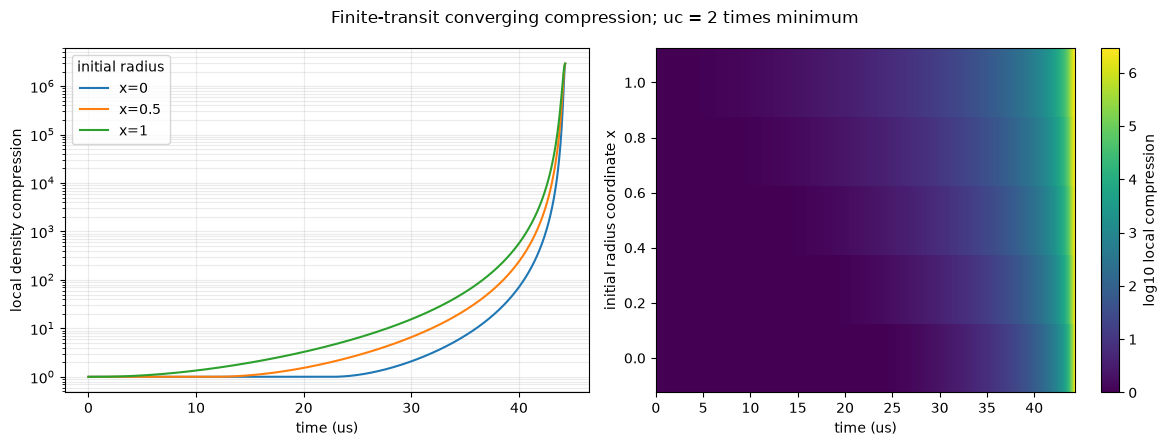

In [4]:
reference = profiles[2.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for index, coordinate in enumerate(reference.mass_coordinate_fraction):
    if coordinate in (0.0, 0.5, 1.0):
        axes[0].semilogy(
            reference.time_s * 1e6,
            reference.local_compression_ratio[index],
            label=f'x={coordinate:g}',
        )
im = axes[1].pcolormesh(
    reference.time_s * 1e6,
    reference.mass_coordinate_fraction,
    np.log10(reference.local_compression_ratio),
    shading='auto',
)
axes[0].set_xlabel('time (us)')
axes[0].set_ylabel('local density compression')
axes[0].grid(which='both', alpha=0.25)
axes[0].legend(title='initial radius')
axes[1].set_xlabel('time (us)')
axes[1].set_ylabel('initial radius coordinate x')
fig.colorbar(im, ax=axes[1], label='log10 local compression')
fig.suptitle('Finite-transit converging compression; uc = 2 times minimum')
plt.tight_layout()

## Central DT trigger window

The following table fires the central trigger when its tagged central volume reaches a selected compression. DT neutrons are then flown to the current fuel surface at 14.1-MeV speed. The local outer and mid-zone compression at neutron arrival is reported. This is timing only: energy deposition remains reaction- and radius-dependent and must be calculated separately.

In [5]:
trigger_rows = []
for trigger_compression in (1e2, 1e3, 1e4, 1e5, 1e6):
    shot = central_trigger_snapshot(reference, trigger_compression)
    trigger_rows.append({
        'central trigger compression': trigger_compression,
        'trigger time (us)': shot.trigger_time_s * 1e6,
        'time remaining (us)': shot.time_before_peak_s * 1e6,
        'fuel radius at trigger (m)': shot.surface_radius_at_trigger_m,
        'surface-average compression': shot.surface_average_compression_at_trigger,
        'neutron flight to surface (ns)': shot.neutron_flight_to_surface_s * 1e9,
        'outer-zone compression at n arrival': shot.outer_zone_compression_at_arrival,
        'mid-zone compression at n arrival': shot.mid_zone_compression_at_arrival,
        'center compression at n arrival': shot.center_compression_at_arrival,
    })
trigger_df = pd.DataFrame(trigger_rows).set_index('central trigger compression')
trigger_df.style.format('{:.5g}')

,trigger time (us),time remaining (us),fuel radius at trigger (m),surface-average compression,neutron flight to surface (ns),outer-zone compression at n arrival,mid-zone compression at n arrival,center compression at n arrival
central trigger compression,,,,,,,,
100.000000,40.464,3.8319,10.765,801.79,208.94,948.93,400.07,118.36
1000.000000,42.515,1.7803,5.0126,7944,97.295,9393.9,3990.9,1184.8
10000.000000,43.471,0.82441,2.3815,74243,46.226,86938,38781,11834
100000.000000,43.923,0.37279,1.2343,5.3892e+05,23.957,6.1599e+05,3.3282e+05,1.196e+05
1000000.000000,44.16,0.13605,0.79319,2.0272e+06,15.396,2.174e+06,1.8021e+06,1.1688e+06


## Nuclear burn clock of the compressed DT trigger

An 8-cm or 25-cm initial equimolar DT sphere is assumed to compress to the same cold-electron overpressure as Constantine and is then heated impulsively to 10 keV. The existing exact-depletion hotspot screen gives its time to 50% DT burn. This tests whether nuclear burn time or trigger delivery controls the window.

In [6]:
hotspot_rows = []
for trigger_compression in (1e3, 1e4, 1e5, 1e6):
    trigger_time = compression_crossing_time_s(reference, 0.0, trigger_compression)
    for initial_dt_radius_m in (0.08, 0.25):
        hotspot = screen_central_dt_hotspot(
            core_initial_density_kg_m3=core_density_kg_m3,
            core_mass_amu_per_unit=17.0,
            core_electrons_per_unit=8.0,
            core_compression_ratio=trigger_compression,
            initial_dt_radius_m=initial_dt_radius_m,
            initial_dt_density_kg_m3=250.0,
            temperature_keV=10.0,
            target_burn_fraction=0.50,
        )
        hotspot_rows.append({
            'central core compression': trigger_compression,
            'initial DT radius (m)': initial_dt_radius_m,
            'DT compression': hotspot.dt_compression_ratio,
            'compressed DT radius (mm)': hotspot.compressed_dt_radius_m * 1e3,
            'DT t50 (ps)': hotspot.burn_time_s * 1e12,
            'DT t50 / local sound crossing': hotspot.burn_time_over_sound_crossing,
            'core time remaining (ns)': (reference.peak_time_s - trigger_time) * 1e9,
        })
pd.DataFrame(hotspot_rows).set_index([
    'central core compression', 'initial DT radius (m)'
]).style.format('{:.5g}')

## Scale lever

At fixed dimensionless driver geometry and speed ratios, compression ratios are unchanged while all mechanical and trigger-window times scale linearly with initial radius. The next table rescales the reference central trigger timing without rerunning the nuclear system. The compressed DT burn time instead falls with increasing achieved density and does not scale with the overall target radius.

In [7]:
scale_rows = []
for radius_m in (10.0, 30.0, 100.0, 300.0, 500.0, 1000.0):
    scale = radius_m / R0_m
    for trigger_compression in (1e4, 1e5):
        shot = central_trigger_snapshot(reference, trigger_compression)
        scale_rows.append({
            'R0 (m)': radius_m,
            'central trigger compression': trigger_compression,
            'trigger time (us)': shot.trigger_time_s * scale * 1e6,
            'time remaining to stagnation (us)': shot.time_before_peak_s * scale * 1e6,
            'fuel radius at trigger (m)': shot.surface_radius_at_trigger_m * scale,
        })
pd.DataFrame(scale_rows).set_index(['R0 (m)', 'central trigger compression']).style.format('{:.5g}')

## Physical interpretation and next coupling

* The model supports the proposed timing mechanism: the outer fuel may be deeply compressed while the center remains comparatively cold, followed by rapid central convergence immediately before stagnation.
* At the 100-m reference and $u_c=2R_0/t_{peak}$, central $C=10^4$ occurs less than 1 microsecond before peak. Once heated, the compressed DT kernel burns in picoseconds, so ignition delivery—not fusion kinetics—sets the trigger precision.
* Increasing target scale widens the same dimensionless trigger window in absolute time. It does not automatically improve symmetry or shock stability.
* Central DT neutrons do not uniformly preheat an enormously compressed core: their physical attenuation lengths shrink as density rises. The next coupling must calculate the heated central radius and evolve the desired low-cross-section fuel burn outward from that region.
* This prescribed convergence is deliberately optimistic. A failed point can rule out its inputs, but a successful point must later survive a Lagrangian hydrodynamics calculation with EOS, entropy, shock merging, radiation, and instability.

The analogy to NIF is specific rather than rhetorical. NIF uses carefully timed shock sequences to control fuel adiabat and compression, and late-shock ignition concepts explicitly separate dense fuel assembly from ignition near stagnation. See [Precision Shock Tuning on NIF](https://doi.org/10.1103/PhysRevLett.108.215004) and the DOE-hosted [shock-ignition design discussion](https://www.osti.gov/servlets/purl/1891734). NIF's April 2025 target gain of 4.13 confirms that such timing can work in real ICF targets; it does not validate this target's much larger scale or different fuel.